# Análise numérica de um circuito RLC em paralelo pelo Método das Diferenças Finitas

Este notebook apresenta a implementação computacional do Método das Diferenças Finitas aplicada ao circuito RLC em paralelo analisado no trabalho. São calculadas a solução numérica, a solução analítica correspondente e o erro absoluto, além de um estudo de refinamento da malha temporal para diferentes valores do passo $h$.


## 1. Bibliotecas


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 2. Parâmetros do problema

Os parâmetros utilizados no estudo são:

- resistência: $R=20\,\Omega$;
- indutância: $L=10\,\mathrm{H}$;
- capacitância: $C=0.004\,\mathrm{F}$;
- tensão inicial: $v(0)=0\,\mathrm{V}$;
- derivada inicial: $v'(0)=-1125\,\mathrm{V/s}$;
- intervalo de simulação: $0\leq t\leq3\,\mathrm{s}$.

O valor $h_{\mathrm{ref}}=0.01\,\mathrm{s}$ é utilizado como passo de referência.
Os valores de `h_values` são utilizados no estudo de refinamento da malha.


In [2]:
# Parâmetros elétricos
R = 20.0
L = 10.0
C = 0.004

# Condições iniciais
v0 = 0.0
vp0 = -1125.0

# Intervalo temporal
t0 = 0.0
tf = 3.0

# Passo de referência
h_ref = 0.01

# Passos analisados no refinamento da malha
# Para testar outros valores, altere somente esta lista.
h_values = [0.02, 0.01, 0.005, 0.0025]


## 3. Formulação computacional

Para o caso analisado, a solução analítica da tensão é

$$
v(t)=150\left(e^{-10t}-e^{-2.5t}\right).
$$

A aproximação numérica é obtida pela relação de recorrência

$$
v_{i+1}=
\frac{\left(2-\frac{h^2}{LC}\right)v_i
-\left(1-\frac{h}{2RC}\right)v_{i-1}}
{1+\frac{h}{2RC}}.
$$

O primeiro ponto da malha é definido por $v_0=v(0)$ e o segundo ponto é aproximado por

$$
v_1=v_0+h\,v'(0).
$$

O erro absoluto em cada instante é calculado por

$$
E_i=\left|v_i-v(t_i)\right|.
$$


In [4]:
def solucao_analitica(t):
    """Retorna a solução analítica do circuito RLC estudado."""
    return 150.0 * (np.exp(-10.0 * t) - np.exp(-2.5 * t))


def diferencas_finitas(h):
    """Calcula a solução numérica e o erro absoluto para um passo temporal h."""
    n_pontos = int(round((tf - t0) / h)) + 1
    t = t0 + np.arange(n_pontos) * h

    v = np.zeros(n_pontos)
    v[0] = v0
    v[1] = v0 + h * vp0

    A = 2.0 - (h**2) / (L * C)
    B = 1.0 - h / (2.0 * R * C)
    D = 1.0 + h / (2.0 * R * C)

    for i in range(1, n_pontos - 1):
        v[i + 1] = (A * v[i] - B * v[i - 1]) / D

    v_exata = solucao_analitica(t)
    erro = np.abs(v - v_exata)

    return t, v, v_exata, erro


## 4. Caso de referência

Para $h=0.01\,\mathrm{s}$, são apresentados valores representativos da solução numérica, da solução analítica e do erro absoluto.


In [5]:
t_ref, v_ref, v_exata_ref, erro_ref = diferencas_finitas(h_ref)

tempos_tabela = [0.00, 0.10, 0.20, 0.50, 1.00, 1.50, 2.00, 2.50, 3.00]

print(
    f"{'Tempo (s)':<12}"
    f"{'Solução numérica (V)':<24}"
    f"{'Solução analítica (V)':<25}"
    f"{'Erro absoluto (V)':<20}"
)
print("-" * 81)

for tempo in tempos_tabela:
    indice = int(round((tempo - t0) / h_ref))

    print(
        f"{t_ref[indice]:<12.2f}"
        f"{v_ref[indice]:<24.6f}"
        f"{v_exata_ref[indice]:<25.6f}"
        f"{erro_ref[indice]:<20.6f}"
    )


Tempo (s)   Solução numérica (V)    Solução analítica (V)    Erro absoluto (V)   
---------------------------------------------------------------------------------
0.00        0.000000                0.000000                 0.000000            
0.10        -65.556884              -61.638201               3.918683            
0.20        -75.134523              -70.679306               4.455216            
0.50        -44.580928              -41.965027               2.615901            
1.00        -13.073029              -12.305940               0.767089            
1.50        -3.748207               -3.527616                0.220591            
2.00        -1.074102               -1.010692                0.063411            
2.50        -0.307796               -0.289568                0.018228            
3.00        -0.088202               -0.082963                0.005239            


## 5. Refinamento da malha temporal

O cálculo é repetido para cada valor presente em `h_values`, mantendo constantes os parâmetros elétricos, as condições iniciais e o intervalo de simulação.


In [6]:
resultados = {}

for h in h_values:
    t_h, v_h, v_exata_h, erro_h = diferencas_finitas(h)

    resultados[h] = {
        "t": t_h,
        "v": v_h,
        "v_exata": v_exata_h,
        "erro": erro_h,
        "erro_maximo": np.max(erro_h),
        "erro_medio": np.mean(erro_h),
    }


### 5.1 Comparação entre as soluções


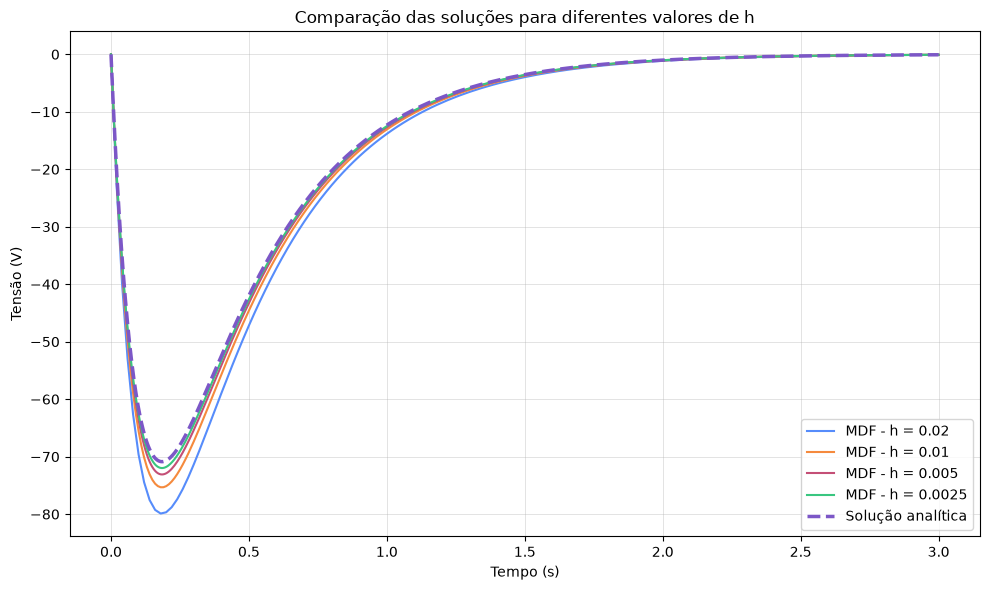

In [7]:
plt.figure(figsize=(10, 6))

for h in h_values:
    plt.plot(
        resultados[h]["t"],
        resultados[h]["v"],
        linewidth=1.5,
        label=f"MDF - h = {h:g}",
    )

t_exato = np.linspace(t0, tf, 2000)

plt.plot(
    t_exato,
    solucao_analitica(t_exato),
    "--",
    linewidth=2.5,
    label="Solução analítica",
)

plt.xlabel("Tempo (s)")
plt.ylabel("Tensão (V)")
plt.title("Comparação das soluções para diferentes valores de h")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 5.2 Erro absoluto


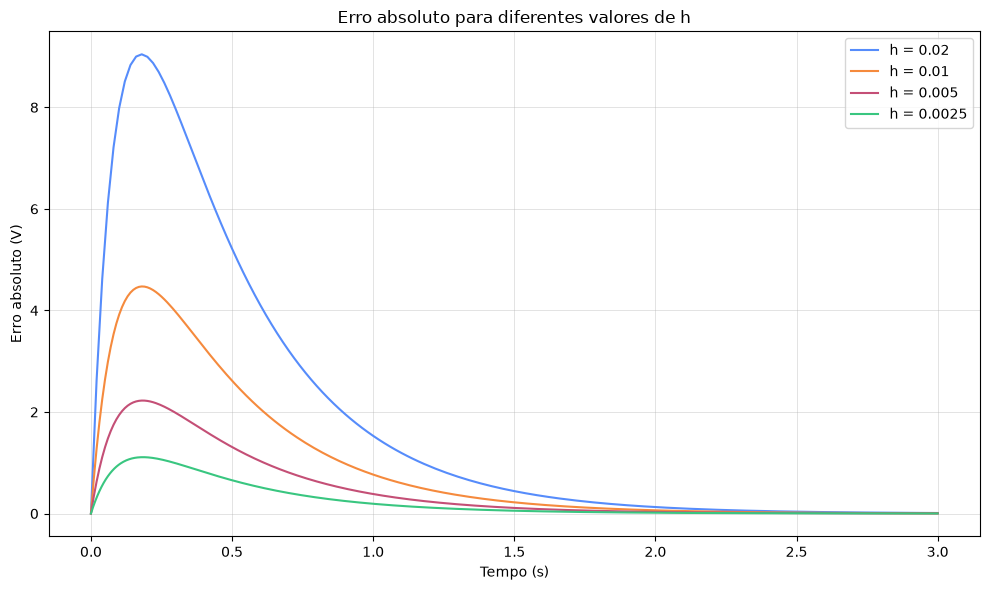

In [8]:
plt.figure(figsize=(10, 6))

for h in h_values:
    plt.plot(
        resultados[h]["t"],
        resultados[h]["erro"],
        linewidth=1.5,
        label=f"h = {h:g}",
    )

plt.xlabel("Tempo (s)")
plt.ylabel("Erro absoluto (V)")
plt.title("Erro absoluto para diferentes valores de h")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 5.3 Erro máximo e erro médio


In [9]:
print(
    f"{'h (s)':<12}"
    f"{'Erro máximo (V)':<22}"
    f"{'Erro médio (V)':<22}"
)
print("-" * 56)

for h in h_values:
    print(
        f"{h:<12.4f}"
        f"{resultados[h]['erro_maximo']:<22.8f}"
        f"{resultados[h]['erro_medio']:<22.8f}"
    )


h (s)       Erro máximo (V)       Erro médio (V)        
--------------------------------------------------------
0.0200      9.04481498            1.87361220            
0.0100      4.47249024            0.93680988            
0.0050      2.22506455            0.46840482            
0.0025      1.10990249            0.23420230            


### 5.4 Razão entre erros máximos sucessivos

Para valores de $h$ ordenados do maior para o menor, a razão abaixo permite comparar a redução do erro máximo durante o refinamento da malha.


In [11]:
print(
    f"{'Refinamento de h':<28}"
    f"{'Razão dos erros máximos':<25}"
)
print("-" * 53)

for i in range(len(h_values) - 1):
    h_atual = h_values[i]
    h_seguinte = h_values[i + 1]

    razao = (
        resultados[h_atual]["erro_maximo"]
        / resultados[h_seguinte]["erro_maximo"]
    )

    print(
        f"{h_atual:.4f} -> {h_seguinte:.4f}"
        f"{'':<10}"
        f"{razao:.4f}"
    )


Refinamento de h            Razão dos erros máximos  
-----------------------------------------------------
0.0200 -> 0.0100          2.0223
0.0100 -> 0.0050          2.0100
0.0050 -> 0.0025          2.0047


## 6. Teste com outros valores de $h$

Para executar o mesmo estudo com outra quantidade de passos, altere somente a lista `h_values` na Seção 2 e execute novamente as Seções 5.1 a 5.4.

Por exemplo, para cinco valores:

```python
h_values = [0.04, 0.02, 0.01, 0.005, 0.0025]
```

Para que a análise das razões entre erros sucessivos represente um refinamento da malha, recomenda-se informar os valores em ordem decrescente.
